In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.constants as pc
import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.table import vstack
from scipy.stats import ttest_rel
import csv

In [73]:
def red_chi_squared(y_values, y_uncertainties, model_data, dof):

  chi_squared = np.sum(((model_data - y_values) / y_uncertainties)**2)

  red_chi = chi_squared / (len(y_values) - dof)

  return chi_squared

In [74]:
def open_csv_table(path):

    table = Table.read(path, format="csv")
    
    print("Table headers: ", table.colnames)
    
    stellar_fields = ["ID", "RA","Dec","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    stellar_AGN_fields = ["ID", "RA","Dec","AGNanBest","AGNlumBest","UV1500AGNBest","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv":
    # Data for stellar only fitting
    # Could probably automate this 
        new_table = table[stellar_fields]
        # Data from fits with just stellar
        
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_astro_cat.csv":
    # Stellar and AGN fit data   
        new_table = table[stellar_AGN_fields]
    
    
    return new_table

In [75]:
def plot_stellar_masses(stellar_only_q16,stellar_only_mass_Q50,stellar_only_q84,
                        stellar_AGN_q16,stellar_AGN_mass_Q50,stellar_AGN_q84):
    """
    Plotting Q50 stellar mass from stars only against Q50 mass from stars and AGN.
    """
    # Convert quantiles into asymmetric error bars
    yerr = [
        np.log10(stellar_only_mass_Q50) - np.log10(stellar_only_q16),
        np.log10(stellar_only_q84) - np.log10(stellar_only_mass_Q50)
    ]
    xerr = [
        np.log10(stellar_AGN_mass_Q50) - np.log10(stellar_AGN_q16),
        np.log10(stellar_AGN_q84) - np.log10(stellar_AGN_mass_Q50)
    ]

    t, p = ttest_rel(stellar_only_mass_Q50, stellar_AGN_mass_Q50)
    print("p value = ",p)

    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.errorbar(
        np.log10(stellar_AGN_mass_Q50),
        np.log10(stellar_only_mass_Q50),
        xerr=xerr,
        yerr=yerr,
        fmt='o',
        ms=4,
        alpha=0.7,
        capsize=2
    )
    
    # 1:1 line
    mmin = min(np.min(np.log10(stellar_AGN_mass_Q50)),np.min(np.log10(stellar_only_mass_Q50)))
    mmax = max(np.max(np.log10(stellar_AGN_mass_Q50)),np.max(np.log10(stellar_only_mass_Q50)))

    ax.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars only)')
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars + AGN)')
    ax.set_ylim(mmin, mmax)
    ax.set_xlim(mmin, mmax)
    ax.set_aspect('equal')
    ax.legend()

    plt.tight_layout()
    plt.show()
    
    return

In [76]:
def check_Q50_mass_against_best(mass_Q16, mass_Q50, mass_Q84, mass_best):
    """
    Plotting stellar mass Q50 and errors (y-axis) against stellar mass best (x-axis).
    Will be done for stellar only data and stellar+AGN data when called separately.
    """
    
    # Convert quantiles into asymmetric error bars
    yerr = [
        np.log10(mass_Q50) - np.log10(mass_Q16),
        np.log10(mass_Q84) - np.log10(mass_Q50)]

    t, p = ttest_rel(mass_best, mass_Q50)
    print("p value = ",p)

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.errorbar(
        np.log10(mass_best),
        np.log10(mass_Q50),
        yerr=yerr,
        fmt='o',
        ms=4,
        alpha=0.7,
        capsize=2
    )
    
    # 1:1 line
    mmin = min(np.min(np.log10(mass_best)),np.min(np.log10(mass_Q50)))
    mmax = max(np.max(np.log10(mass_best)),np.max(np.log10(mass_Q50)))

    ax.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Best)')
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)')
    ax.set_ylim(mmin, mmax)
    ax.set_xlim(mmin, mmax)
    ax.set_aspect('equal')
    ax.legend()

    plt.tight_layout()
    plt.show()

    return

In [77]:
def straight_line(x, m, c):
   
    y=m*x + c
   
    return y

In [78]:
def compare_stellar_mass_shay_vs_ProSpect(fits_table, mass_Q16, mass_Q50, mass_Q84):

    bh_mass = fits_table["BH_MASS"].data
    bh_mass_err = fits_table["BH_MASS_ERR"].data

    log10_mass_upper_err = np.log10(mass_Q84) - np.log10(mass_Q50)
    log10_mass_lower_err = np.log10(mass_Q50) - np.log10(mass_Q16)

    """
    bhsmr = bh_mass / mass_Q50

    bhsmr_upper_err = bhsmr * np.sqrt( (bh_mass_err / bh_mass)**2 + (mass_lower_err / mass_Q50)**2 )
    bhsmr_lower_err = bhsmr * np.sqrt( (bh_mass_err / bh_mass)**2 + (mass_upper_err / mass_Q50)**2 )
    """
    popt, pcov = curve_fit(straight_line, np.log10(mass_Q50), bh_mass, p0=None)

    gradient = popt[0]
    intercept = popt[1]

    gradient_uncertainty = np.sqrt(np.diag(pcov))[0]
    intercept_uncertainty = np.sqrt(np.diag(pcov))[1]

    x_data = np.linspace(np.min(np.log10(mass_Q50)),np.max(np.log10(mass_Q50)),1000)
    

    red_chi = red_chi_squared(bh_mass, bh_mass_err, straight_line(np.log10(mass_Q50), gradient, intercept),2)


    fig, ax = plt.subplots(figsize=(10, 10))
    """
    ax.errorbar(
        np.log10(mass_Q50),
        np.log10(bh_mass),
        xerr = [log10_mass_lower_err, log10_mass_upper_err],
        yerr=np.log10(bh_mass_err),
        fmt='o',
        ms=4,
        alpha=0.7,
        capsize=2
    )
    """
    ax.scatter(np.log10(mass_Q50), bh_mass)

    ax.plot(x_data, straight_line(x_data, gradient, intercept), label="Line of best fit")

    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)')
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)')
    plt.xlim(5,12)
    ax.set_aspect('equal')
    ax.legend()

    
    plt.show()
    print("Equation of best fit line gradient = ", gradient,"+-", gradient_uncertainty)
    print("Equation of best fit line intercept = ", intercept,"+-", intercept_uncertainty)
    print("reduced chi squared = ", red_chi)

    return

In [79]:
def open_fits_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)
        #print("Number of objects = ", len(tbl))
        return tbl


Table headers:  ['mSFRBest', 'mpeakBest', 'mperiodBest', 'mskewBest', 'tau_birthBest', 'tau_screenBest', 'alpha_SF_birthBest', 'alpha_SF_screenBest', 'ZfinalBest', 'StellarMassBest', 'SFR10Best', 'SFR100Best', 'UV1500Best', 'UV1500AGNBest', 'DustLumBirthBest', 'DustLumScreenBest', 'DustLumTotalBest', 'DustMassBirthBest', 'DustMassScreenBest', 'DustMassTotalBest', 'NgasMassBirthBest', 'NgasMassScreenBest', 'NgasMassTotalBest', 'LPBest', 'mSFRQ50', 'mpeakQ50', 'mperiodQ50', 'mskewQ50', 'tau_birthQ50', 'tau_screenQ50', 'alpha_SF_birthQ50', 'alpha_SF_screenQ50', 'ZfinalQ50', 'StellarMassQ50', 'SFR10Q50', 'SFR100Q50', 'UV1500Q50', 'UV1500AGNQ50', 'DustLumBirthQ50', 'DustLumScreenQ50', 'DustLumTotalQ50', 'DustMassBirthQ50', 'DustMassScreenQ50', 'DustMassTotalQ50', 'NgasMassBirthQ50', 'NgasMassScreenQ50', 'NgasMassTotalQ50', 'LPQ50', 'mSFRQ16', 'mpeakQ16', 'mperiodQ16', 'mskewQ16', 'tau_birthQ16', 'tau_screenQ16', 'alpha_SF_birthQ16', 'alpha_SF_screenQ16', 'ZfinalQ16', 'StellarMassQ16', 'SFR1

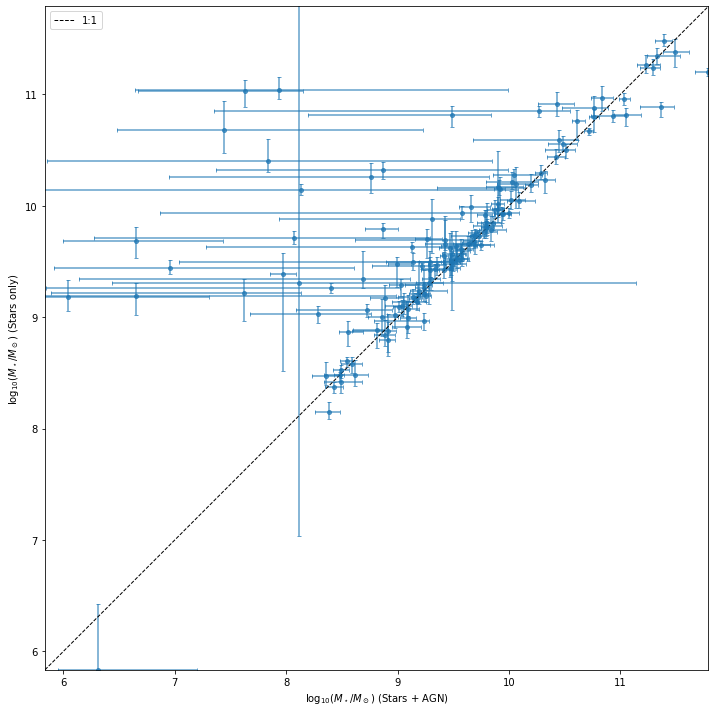

p value =  0.37254242645448743


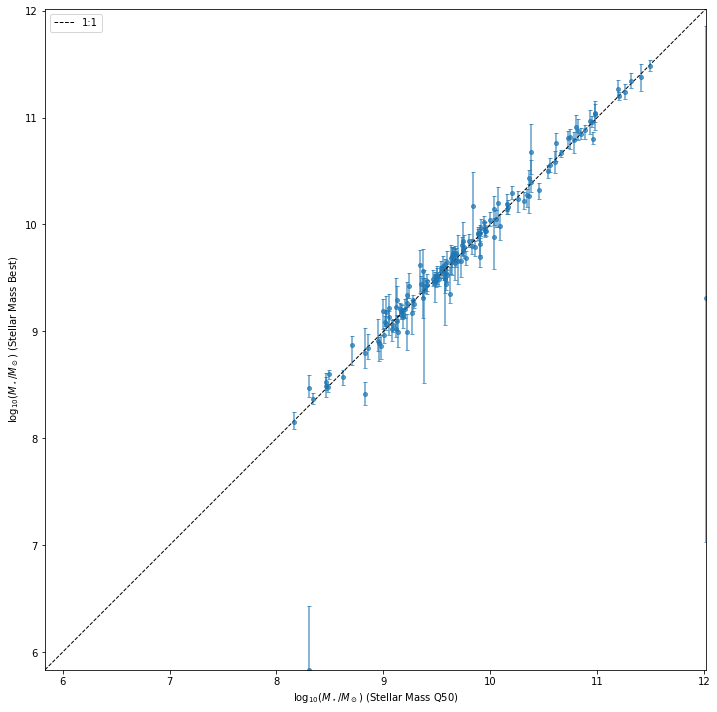

p value =  0.14975704418717092


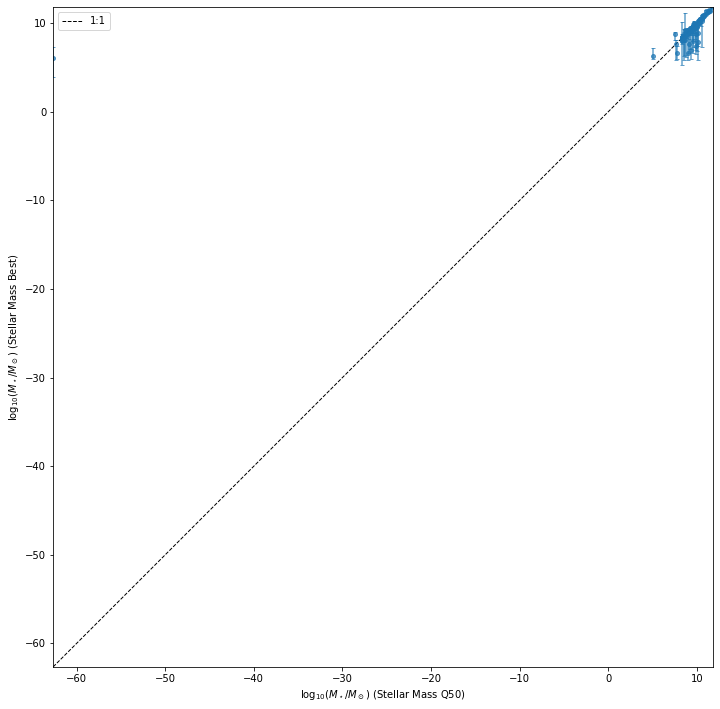

Filename: /nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     54   144R x 23C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 18A, 21A, J]   


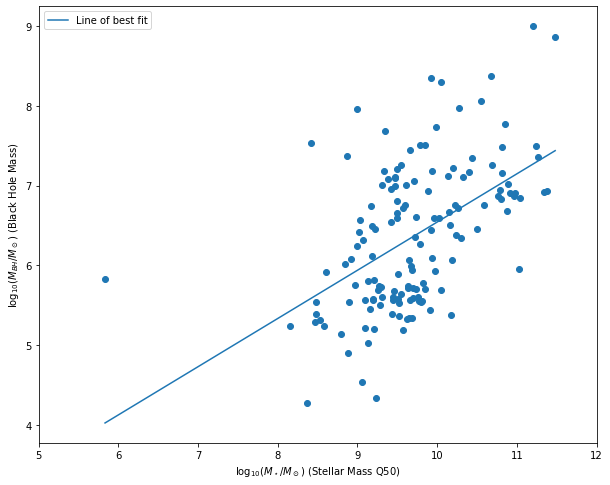

Equation of best fit line gradient =  0.6049498129135593 +- 0.084200080354805
Equation of best fit line intercept =  0.4935013824329494 +- 0.8197097949737475
reduced chi squared =  2.2156714165119036


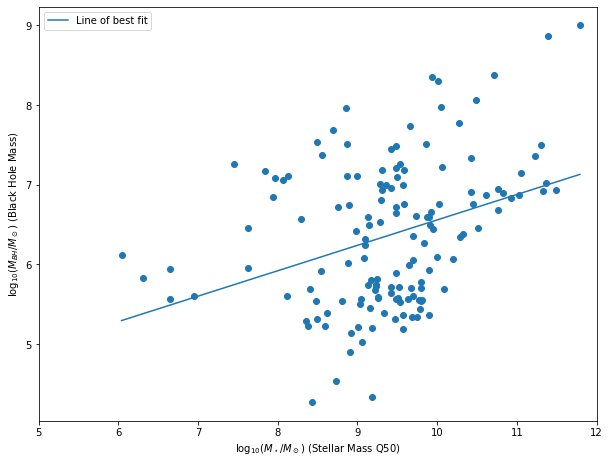

Equation of best fit line gradient =  0.318919144110168 +- 0.07227862455275699
Equation of best fit line intercept =  3.369991133952898 +- 0.68233842209312
reduced chi squared =  2.7655717298078946


In [80]:
if __name__ == "__main__":
    

    stellar_only_table = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv")
    
    stellar_AGN_table = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_astro_cat.csv")
    
    # Stellar only mass data:
    stellar_only_mass_best = stellar_only_table["StellarMassBest"].data
    stellar_only_mass_Q16 = stellar_only_table["StellarMassQ16"].data
    stellar_only_mass_Q50 = stellar_only_table["StellarMassQ50"].data
    stellar_only_mass_Q84 = stellar_only_table["StellarMassQ84"].data

    # Stellar+AGN mass data:
    stellar_AGN_mass_best = stellar_AGN_table["StellarMassBest"].data
    stellar_AGN_mass_Q16 = stellar_AGN_table["StellarMassQ16"].data
    stellar_AGN_mass_Q50 = stellar_AGN_table["StellarMassQ50"].data
    stellar_AGN_mass_Q84 = stellar_AGN_table["StellarMassQ84"].data
    

    plot_stellar_masses(stellar_only_mass_Q16, stellar_only_mass_Q50, stellar_only_mass_Q84,
                        stellar_AGN_mass_Q16, stellar_AGN_mass_Q50, stellar_AGN_mass_Q84)
    
    check_Q50_mass_against_best(stellar_only_mass_Q16, stellar_only_mass_Q50, stellar_only_mass_Q84,
                                stellar_only_mass_best)
    # Compares stellar only mass Q50 against best
    
    check_Q50_mass_against_best(stellar_AGN_mass_Q16, stellar_AGN_mass_Q50, stellar_AGN_mass_Q84,
                                stellar_AGN_mass_best)
    # Compares stellar+AGN mass Q50 against best

    galaxy_data = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits")


    compare_stellar_mass_shay_vs_ProSpect(galaxy_data, 
                                          stellar_only_mass_Q16, stellar_only_mass_Q50, stellar_only_mass_Q84)
    
    compare_stellar_mass_shay_vs_ProSpect(galaxy_data, 
                                          stellar_AGN_mass_Q16, stellar_AGN_mass_Q50, stellar_AGN_mass_Q84)
    
    